In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                  
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 3/12        # years                 
dt = 10.0       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=2)                                                                                                    
         

In [3]:
waveform_response

In [4]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=2)

# no noise check

In [6]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

loglike_obj = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), 

In [7]:
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.7004, rho=0.8369
  Mode 1: <hf|hf>_timemax=3.156, rho=1.776
  Mode 2: <hf|hf>_timemax=20.99, rho=4.582
  Mode 3: <hf|hf>_timemax=27.53, rho=5.247
  Mode 4: <hf|hf>_timemax=17.88, rho=4.228
  Mode 5: <hf|hf>_timemax=7.734, rho=2.781
  Mode 6: <hf|hf>_timemax=2.609, rho=1.615
rho_m: [0.83692576 1.77648871 4.58166244 5.24684379 4.22805135 2.78094104
 1.61530847]
Dominant mode index: 3, rho: 5.247
beta=0.05257, rho_dom_M=5.247, rho_tot=9.518
X_scalar (time-maximized): 9.518
Time-maximized Log-likelihood: 9.45935
9.459349963737003


In [8]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.6698, rho=0.8184
  Mode 1: <hf|hf>_timemax=3.021, rho=1.738
  Mode 2: <hf|hf>_timemax=20.24, rho=4.498
  Mode 3: <hf|hf>_timemax=26.77, rho=5.174
  Mode 4: <hf|hf>_timemax=17.54, rho=4.188
  Mode 5: <hf|hf>_timemax=7.645, rho=2.765
  Mode 6: <hf|hf>_timemax=2.591, rho=1.61
rho_m: [0.81841915 1.73807233 4.49841262 5.17365062 4.18752936 2.76494673
 1.60969426]
Dominant mode index: 3, rho: 5.174
beta=0.05346, rho_dom_M=5.174, rho_tot=9.395
X_scalar (time-maximized): 1.703
Time-maximized Log-likelihood: 0.939605
0.9396050640734083


# check with noise/

In [9]:


loglike_obj_noise = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [10]:
#loglike at true param
logl_true_noise=loglike_obj_noise(params)
print(logl_true_noise)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.7004, rho=0.8369
  Mode 1: <hf|hf>_timemax=3.156, rho=1.776
  Mode 2: <hf|hf>_timemax=20.99, rho=4.582
  Mode 3: <hf|hf>_timemax=27.53, rho=5.247
  Mode 4: <hf|hf>_timemax=17.88, rho=4.228
  Mode 5: <hf|hf>_timemax=7.734, rho=2.781
  Mode 6: <hf|hf>_timemax=2.609, rho=1.615
rho_m: [0.83692576 1.77648871 4.58166244 5.24684379 4.22805135 2.78094104
 1.61530847]
Dominant mode index: 3, rho: 5.247
beta=0.05257, rho_dom_M=5.247, rho_tot=9.518
X_scalar (time-maximized): 8.269
Time-maximized Log-likelihood: 4.34813
4.3481313967385855


In [11]:
                                                                                                                                                                                       
logl_perturbed_noise = loglike_obj_noise(params_perturbed)                                                                                                                                                                               
print(logl_perturbed_noise)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.6698, rho=0.8184
  Mode 1: <hf|hf>_timemax=3.021, rho=1.738
  Mode 2: <hf|hf>_timemax=20.24, rho=4.498
  Mode 3: <hf|hf>_timemax=26.77, rho=5.174
  Mode 4: <hf|hf>_timemax=17.54, rho=4.188
  Mode 5: <hf|hf>_timemax=7.645, rho=2.765
  Mode 6: <hf|hf>_timemax=2.591, rho=1.61
rho_m: [0.81841915 1.73807233 4.49841262 5.17365062 4.18752936 2.76494673
 1.60969426]
Dominant mode index: 3, rho: 5.174
beta=0.05346, rho_dom_M=5.174, rho_tot=9.395
X_scalar (time-maximized): 4.548
Time-maximized Log-likelihood: 2.27694
2.2769448946822513


# check orthogonality

In [12]:
waveforms_per_group = []


In [13]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [14]:
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [15]:
waveforms = [   
    cp.array(waveform_response(*params, T=T, dt=dt, mode_selection=g, include_minus_mkn=False))                                                                                    
    for g in groups                                                                                                                                                                
]

In [16]:
n = len(groups)                                                                                                                                                                    
overlap_matrix = np.zeros((n, n))
                                                                                                                                                                                    
for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])                                                                                                                                         
        overlap_matrix[i, j] = float(cp.real(gwf.overlap(hi_f, hj_f)))   

In [17]:
# Display as heatmap
labels = [                                                                                                                                                                                       
    r'$\sum_m h_{2,m,-1}$',                                                      
    r'$\sum_m h_{2,m,0}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,1}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,2}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,3}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,4}$',                                                                                                                                                                       
    r'$\sum_m h_{2,m,5}$',
]

In [18]:
import matplotlib.pyplot as plt

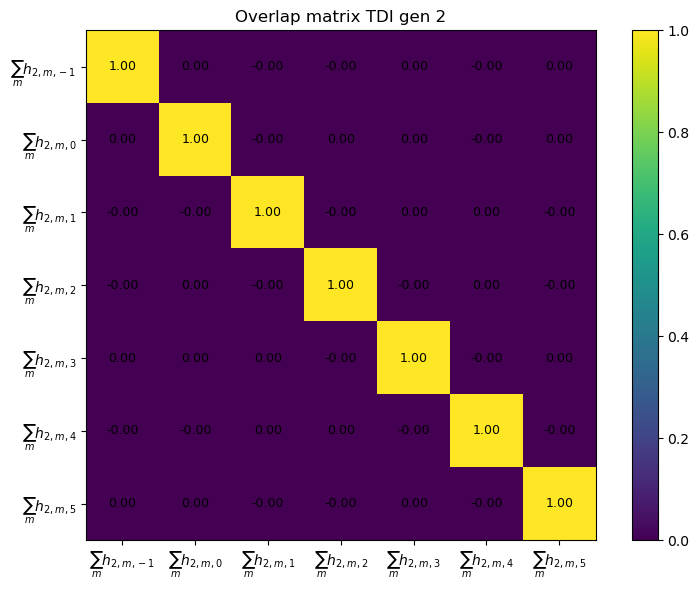

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                             
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)                                                                                                                                
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_title('Overlap matrix TDI gen 2')                                                                                                                                          
plt.colorbar(im, ax=ax)
for i in range(n):                                                                                                                                                                 
    for j in range(n):                                                                                                                                                             
        ax.text(j, i, f'{overlap_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()                                                                                                                                                                 
plt.show() 

In [20]:
overlap_matrix

array([[ 1.00000000e+00,  2.54130141e-05, -6.48023579e-05,
        -2.41073232e-05,  1.32282751e-04, -2.27335971e-05,
         2.66674854e-04],
       [ 2.54130141e-05,  1.00000000e+00, -3.39131745e-05,
         1.21190045e-04,  1.82674356e-05, -9.04723829e-05,
         5.73723244e-05],
       [-6.48023579e-05, -3.39131745e-05,  1.00000000e+00,
        -2.09990218e-05,  2.66480696e-05,  2.80523034e-05,
        -1.77019881e-04],
       [-2.41073232e-05,  1.21190045e-04, -2.09990218e-05,
         1.00000000e+00, -6.22895409e-05,  2.48498744e-05,
        -5.94234619e-05],
       [ 1.32282751e-04,  1.82674356e-05,  2.66480696e-05,
        -6.22895409e-05,  1.00000000e+00, -1.33692186e-05,
         6.86642154e-04],
       [-2.27335971e-05, -9.04723829e-05,  2.80523034e-05,
         2.48498744e-05, -1.33692186e-05,  1.00000000e+00,
        -3.90354126e-05],
       [ 2.66674854e-04,  5.73723244e-05, -1.77019881e-04,
        -5.94234619e-05,  6.86642154e-04, -3.90354126e-05,
         1.0000000

# 2yr with noise

In [21]:
gwf_2yr=GravWaveAnalysis(T=2, dt=dt, use_gpu=True,tdi_gen=1)
waveform_response_2yr = build_waveform_response(T=2, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    

loglike_2yr = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response_2yr,                                                                                                                                                                            
    gwf=gwf_2yr,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 12623.259905418237 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [22]:
#loglike at true param
logl_2yr=loglike_2yr(params)
print(logl_2yr)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=99.83, rho=9.991
  Mode 1: <hf|hf>_timemax=803.5, rho=28.35
  Mode 2: <hf|hf>_timemax=799.6, rho=28.28
  Mode 3: <hf|hf>_timemax=342.5, rho=18.51
  Mode 4: <hf|hf>_timemax=114.5, rho=10.7
  Mode 5: <hf|hf>_timemax=33.11, rho=5.754
  Mode 6: <hf|hf>_timemax=8.555, rho=2.925
rho_m: [ 9.99140524 28.34532001 28.27725904 18.50576354 10.69914148  5.75375192
  2.92486034]
Dominant mode index: 1, rho: 28.35
beta=0.003953, rho_dom_M=28.35, rho_tot=49.95
X_scalar (time-maximized): 51
Time-maximized Log-likelihood: 47.7499
47.749907751078105
